In [1]:
import pandas as pd 
import numpy as np 
import datetime
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_squared_error, r2_score 
from sklearn.model_selection import train_test_split 
import math
import plotly as pl

Shape of Dataset:
(62833, 23)

First 5 Rows:
        X1       ID Case Number                    Date  \
0  4506608  9878952    HX529642  12/04/2014 09:30:00 AM   
1   561379  2514319    HH857213  12/24/2002 09:00:00 AM   
2  5058884  3891396    HL266026  03/31/2005 11:46:00 AM   
3  3619502  4983700    HM446634  06/30/2006 04:44:00 PM   
4  5533749  5284225    HM654977  10/11/2006 11:05:00 PM   

                   Block  IUCR       Primary Type  \
0        010XX E 47TH ST  0497            BATTERY   
1  055XX W CONGRESS PKWY  1320    CRIMINAL DAMAGE   
2    050XX N KIMBALL AVE  141C  WEAPONS VIOLATION   
3    034XX W CHICAGO AVE  2092          NARCOTICS   
4     007XX S CICERO AVE  1506       PROSTITUTION   

                                      Description     Location Description  \
0  AGGRAVATED DOMESTIC BATTERY: OTHER DANG WEAPON                APARTMENT   
1                                      TO VEHICLE                    OTHER   
2                  UNLAWFUL USE OTHER DANG WEAP

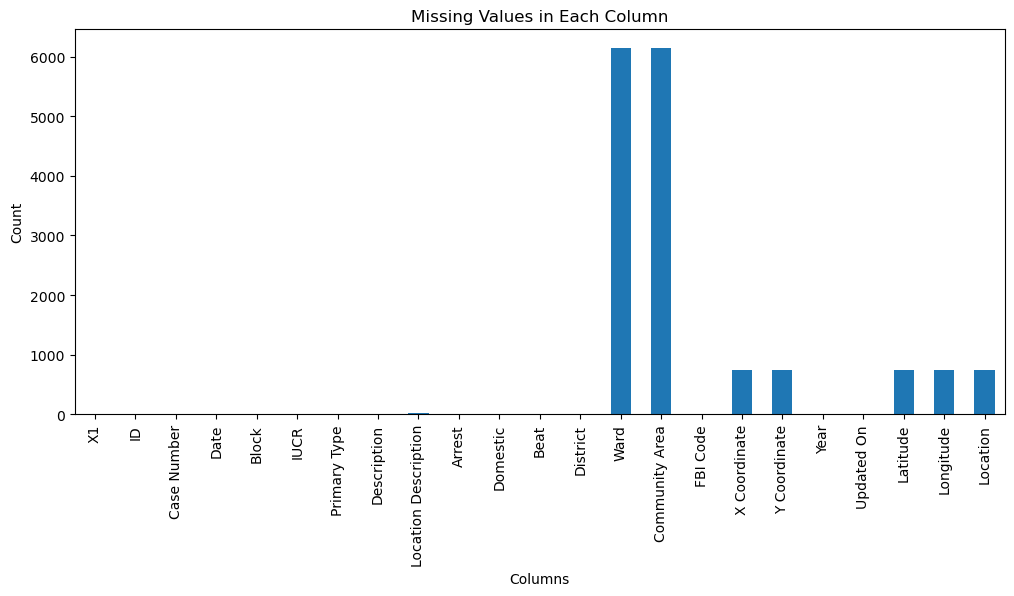


Duplicate Rows:
0


In [36]:
#### Get raw data ## Load in each file

import pandas as pd
import matplotlib.pyplot as plt

column_names = [
    'X1', 'ID', 'Case Number', 'Date', 'Block', 'IUCR',
    'Primary Type', 'Description', 'Location Description',
    'Arrest', 'Domestic', 'Beat', 'District', 'Ward',
    'Community Area', 'FBI Code', 'X Coordinate',
    'Y Coordinate', 'Year', 'Updated On',
    'Latitude', 'Longitude', 'Location'
]

# Read CSV
df = pd.read_csv(
    'Crimes_2001_to_present_sample.csv',
    encoding='utf-8',
    names=column_names,
    skiprows=1,
    low_memory=False
)

# -------------------------------
# DATA INSPECTION
# -------------------------------

print("Shape of Dataset:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())

print("\nColumn Names:")
print(df.columns)

print("\nDataset Info:")
df.info()

print("\nStatistical Summary:")
print(df.describe(include="all"))

print("\nMissing Values:")
print(df.isnull().sum())

print("\nMissing Value Percentage:")
print((df.isnull().sum() / len(df)) * 100)

# Visualize Missing Values
plt.figure(figsize=(12, 5))
df.isnull().sum().plot(kind="bar")
plt.title("Missing Values in Each Column")
plt.xlabel("Columns")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

print("\nDuplicate Rows:")
print(df.duplicated().sum())

In [40]:
# Rename Date column
df = df.rename(columns={"Date": "Datetime"})


# Change data types

def trim_fraction(text):
    if '.0' in text:
        return text[:text.rfind('.0')]
    return text

df['ID'] = df['ID'].astype('str')
df['ID'] = df['ID'].apply(trim_fraction)

df['Case Number'] = df['Case Number'].astype(str)
df['Datetime'] = df['Datetime'].astype(str)
df['Block'] = df['Block'].astype(str)
df['Primary Type'] = df['Primary Type'].astype(str)
df['Description'] = df['Description'].astype(str)
df['Location Description'] = df['Location Description'].astype(str)
df['Arrest'] = df['Arrest'].astype(str)
df['Domestic'] = df['Domestic'].astype(str)

df['Beat'] = pd.to_numeric(df['Beat'], errors='coerce')
df['District'] = pd.to_numeric(df['District'], errors='coerce')
df['Ward'] = pd.to_numeric(df['Ward'], errors='coerce')
df['Community Area'] = pd.to_numeric(df['Community Area'], errors='coerce')
df['FBI Code'] = df['FBI Code'].astype(str)
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df['Updated On'] = df['Updated On'].astype(str)
df['Latitude'] = pd.to_numeric(df['Latitude'], errors='coerce')
df['Longitude'] = pd.to_numeric(df['Longitude'], errors='coerce')

In [32]:
##	Change data types for all columns

df['Case Number'] = df['Case Number'].astype(str)

df['Datetime'] = df['Datetime'].astype(str)

df['Block'] = df['Block'].astype(str)

df['Primary Type'] = df['Primary Type'].astype(str)

df['Description'] = df['Description'].astype(str)

df['Location Description'] = df['Location Description'].astype(str)

df['Arrest'] = df['Arrest'].astype(str)

In [18]:
df['Domestic'] = df['Domestic'].astype(str)

df['Beat'] = pd.to_numeric(df['Beat'], errors='coerce')

df['District'] = pd.to_numeric(df['District'], errors='coerce')

df['Ward'] = pd.to_numeric(df['Ward'], errors='coerce')

df['Community Area'] = pd.to_numeric(df['Community Area'], errors='coerce')

df['FBI Code'] = df['FBI Code'].astype(str)

df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

df['Updated On'] = df['Updated On'].astype(str)

df['Latitude'] = pd.to_numeric(df['Latitude'], errors='coerce')

df['Longitude'] = pd.to_numeric(df['Longitude'], errors='coerce')


In [48]:
### Create datetimes

df['Datetime'] = pd.to_datetime(
    df['Datetime'],
    format="%m/%d/%Y %I:%M:%S %p",
    errors='coerce'
)

df['Updated On'] = pd.to_datetime(
    df['Updated On'],
    format="%m/%d/%Y %I:%M:%S %p",
    errors='coerce'
)

#### Create columns

###	Create columns from datetime ## Month name

df['Month'] = df['Datetime'].dt.strftime('%B') ## Month

df['Month Value'] = df['Datetime'].dt.month ## Year Month

df['Year Month'] = df['Datetime'].dt.strftime('%Y-%m') ## Hour

df['Hour'] = df['Datetime'].dt.hour

# -------------------------------
# FEATURE ENGINEERING
# -------------------------------

# Day of Month
df['Day'] = df['Datetime'].dt.day

# Day Name (Monday, Tuesday, ...)
df['Day Name'] = df['Datetime'].dt.day_name()

# Day of Week (0 = Monday, 6 = Sunday)
df['Day of Week'] = df['Datetime'].dt.dayofweek

# Week Number
df['Week'] = df['Datetime'].dt.isocalendar().week.astype(int)

# Quarter
df['Quarter'] = df['Datetime'].dt.quarter

# Weekend or Weekday
df['Is Weekend'] = df['Day of Week'].isin([5, 6])

In [52]:
####	Create unique identifier ## Create unique identifier

df['Identifier'] = df['ID'] + '-' + df['Case Number'] ## Remove duplicates

df = df.sort_values(['Updated On'], ascending=False)
df = df.drop_duplicates('Identifier')
print("Shape After Removing Duplicates:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())

print("\nColumns After Feature Engineering:")
print(df.columns)

#### Crime rate per month per District

## Get crime counts for each Primary Type

dfDistrict = df.groupby(
    ['Year Month', 'District', 'Primary Type']
).size().reset_index()

dfDistrict = dfDistrict.rename(columns={0: 'Numerator'})

dfDistrict['ID'] = (
    dfDistrict['Year Month'] + " " +
    dfDistrict['District'].astype(str)
)

## Get crime counts for each month

dfMonth = df.groupby(
    ['Year Month', 'District']
).size().reset_index()

dfMonth = dfMonth.rename(columns={0: 'Denominator'})

dfMonth['ID'] = (
    dfMonth['Year Month'] + " " +
    dfMonth['District'].astype(str)
)

dfMonth = dfMonth[['ID', 'Denominator']]

## Join numerator and denominator

dfJoin = pd.merge(dfDistrict, dfMonth, how='left')

dfJoin['Crime Rate'] = (
    dfJoin['Numerator'] /
    dfJoin['Denominator']
) * 100

Shape After Removing Duplicates:
(62833, 34)

First 5 Rows:
          X1        ID Case Number            Datetime               Block  \
1904   42004  10864155    JA170514 2017-02-28 17:05:00  008XX S WABASH AVE   
7134   41998  10864144    JA170515 2017-02-28 18:50:00  007XX N KEDZIE AVE   
25281  41870  10863889    JA169933 2017-02-28 12:05:00    037XX N BELL AVE   
14650  42250  10867973    JA174089 2017-02-28 15:00:00  063XX S DREXEL AVE   
49077  42230  10866393    JA172804 2017-02-28 21:15:00  036XX N TALMAN AVE   

       IUCR                Primary Type                    Description  \
1904   2210        LIQUOR LAW VIOLATION  SELL/GIVE/DEL LIQUOR TO MINOR   
7134   0890                       THEFT                  FROM BUILDING   
25281  0820                       THEFT                 $500 AND UNDER   
14650  1750  OFFENSE INVOLVING CHILDREN                    CHILD ABUSE   
49077  0460                     BATTERY                         SIMPLE   

          Location Descrip

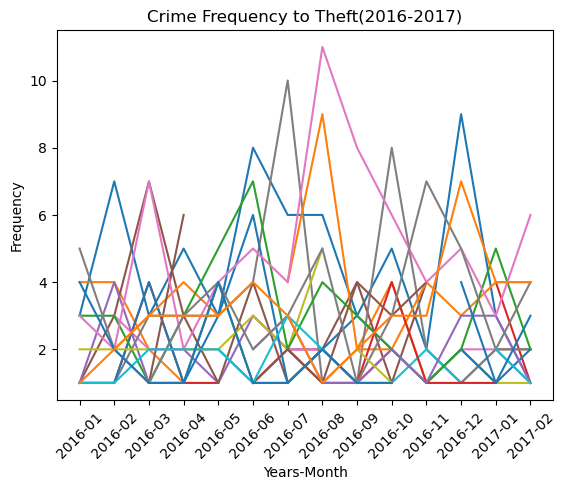

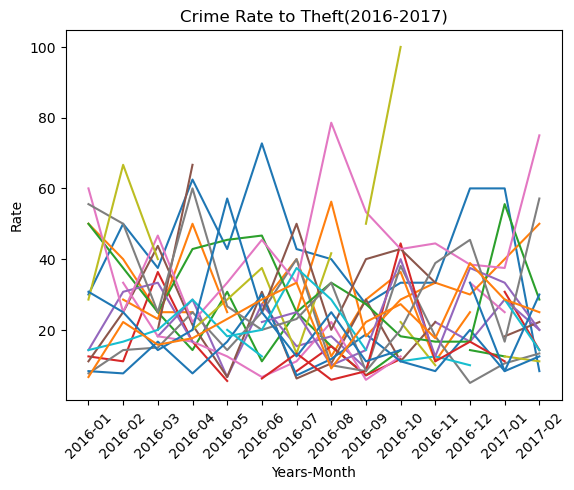

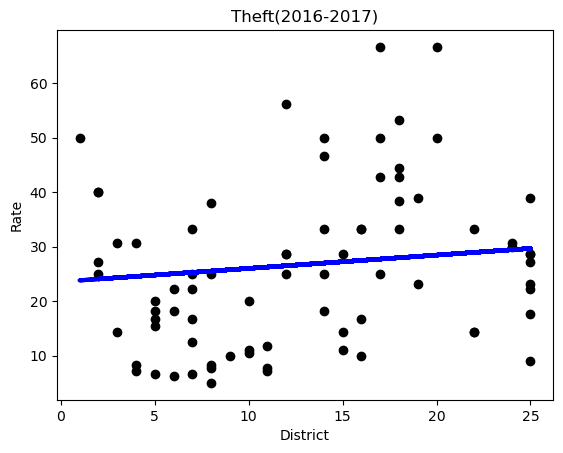

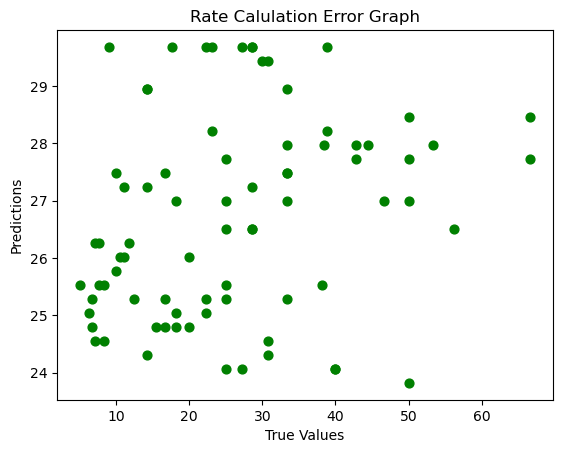

KPI SUMMARY
Total Crimes : 62833
Total Districts : 22
Total Crime Types : 29
Most Common Crime :
THEFT
Top 10 Crime Types :
Primary Type
THEFT                  13015
BATTERY                11508
CRIMINAL DAMAGE         7215
NARCOTICS               6934
OTHER OFFENSE           3880
ASSAULT                 3834
BURGLARY                3684
MOTOR VEHICLE THEFT     2927
ROBBERY                 2338
DECEPTIVE PRACTICE      2320
Name: count, dtype: int64
Top 10 Districts :
District
8.0     4325
11.0    4070
25.0    3732
7.0     3681
4.0     3611
6.0     3576
3.0     3311
9.0     3144
2.0     3051
12.0    2937
Name: count, dtype: int64


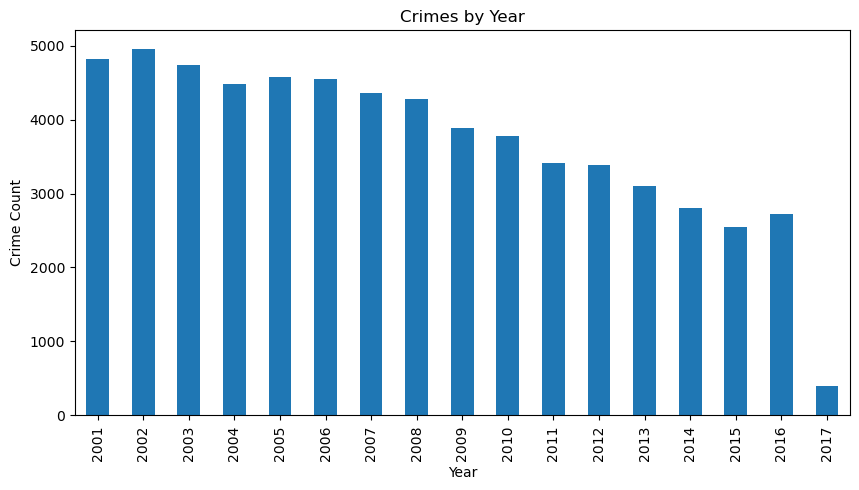

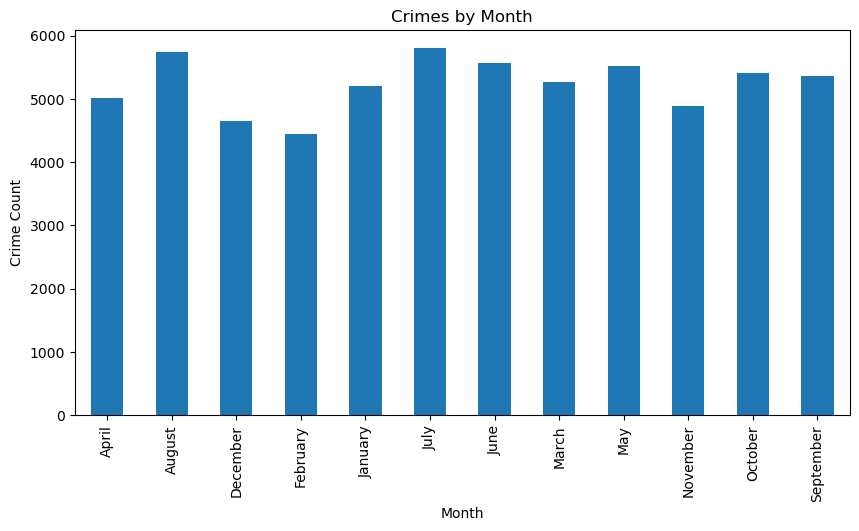

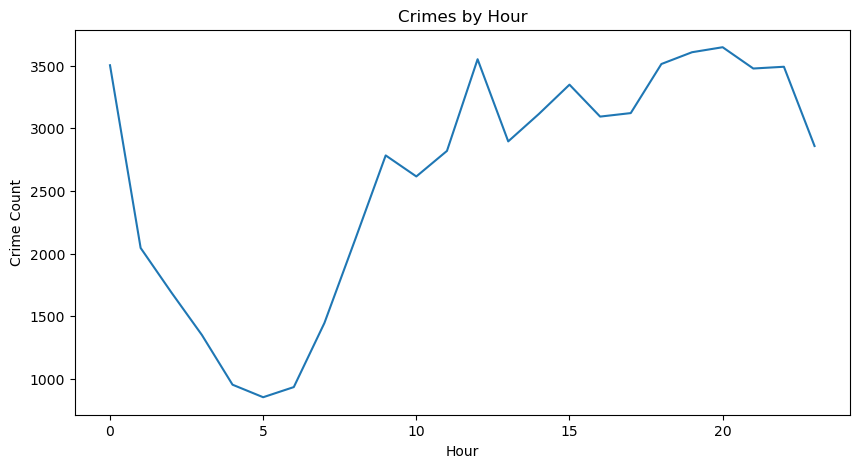

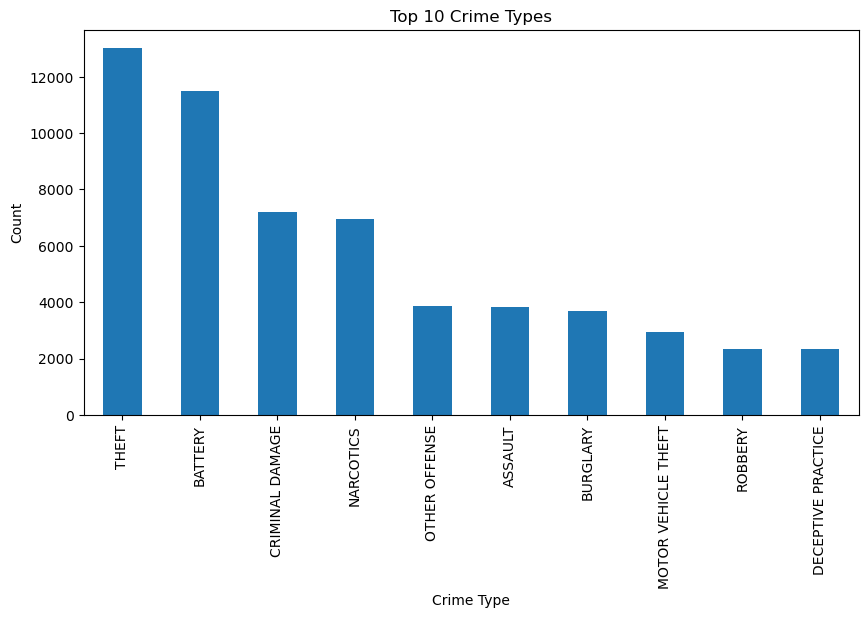

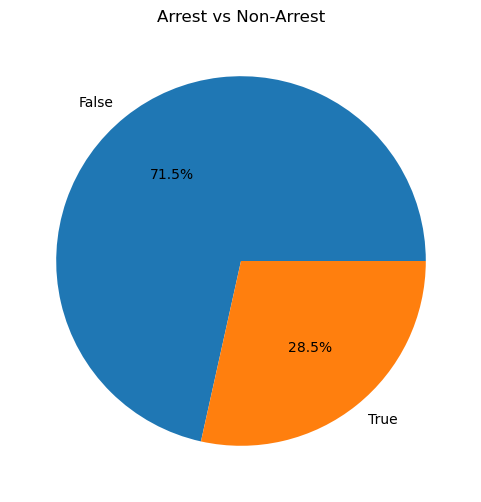

                      X1      Beat  District      Ward  Community Area  \
X1              1.000000 -0.011946 -0.008694 -0.007907        0.008897   
Beat           -0.011946  1.000000  0.934727  0.643379       -0.508505   
District       -0.008694  0.934727  1.000000  0.694552       -0.500916   
Ward           -0.007907  0.643379  0.694552  1.000000       -0.535828   
Community Area  0.008897 -0.508505 -0.500916 -0.535828        1.000000   
X Coordinate    0.005424 -0.467521 -0.524061 -0.428461        0.249326   
Y Coordinate   -0.009468  0.606920  0.614281  0.613603       -0.733020   
Year            0.080294 -0.029392  0.001879  0.017017       -0.004342   
Latitude       -0.009476  0.607020  0.614586  0.613465       -0.731801   
Longitude       0.005448 -0.465761 -0.523101 -0.426213        0.242415   
Month Value    -0.002967  0.008871  0.009777  0.004434       -0.010694   
Hour           -0.000623 -0.006220 -0.007878 -0.003014        0.008086   
Day             0.001017 -0.010183 -0.

In [54]:
## Get crime counts for each Primary Type

dfDistrict = df.groupby(['Year Month', 'District', 'Primary Type']).size().reset_index()

dfDistrict = dfDistrict.rename(columns={0:'Numerator'})

dfDistrict['ID'] = dfDistrict['Year Month'] + ' ' + dfDistrict['District'].astype(str)




## Get crime counts for each month

dfMonth = df.groupby(['Year Month', 'District']).size().reset_index()

dfMonth = dfMonth.rename(columns={0:'Denominator'})

dfMonth['ID'] = dfMonth['Year Month'] + ' ' + dfMonth['District'].astype(str)

dfMonth = dfMonth[['ID', 'Denominator']]


##	Join to get numerator and denominator together 
dfJoin = pd.merge(dfDistrict, dfMonth, how='left')

dfJoin['Crime Rate'] = dfJoin['Numerator']/dfJoin['Denominator'] * 100


#### Visualisation


## Prepare data frame for Theft from 2016

dfPrimaryType = dfJoin[(dfJoin['Primary Type'] == "THEFT")].reset_index()
dfPrimaryType = dfPrimaryType[(dfPrimaryType['Year Month'] > "2015-12")]




### Plots


## Crime frequency - theft

dfCrimeFreq = dfPrimaryType.pivot(index='Year Month', columns='District')['Numerator']

dfCrimeFreq = dfCrimeFreq.reset_index()

x = list(range(dfCrimeFreq.shape[0]))

y = dfCrimeFreq.drop(['Year Month'], axis=1)

plt.plot(x, y)

xticks = dfCrimeFreq['Year Month']

plt.xticks(x, xticks, rotation=45)

plt.title('Crime Frequency to Theft(2016-2017)')

plt.xlabel('Years-Month')

 
plt.ylabel('Frequency')

plt.show()

## Crime rate - theft

dfCrimeRate = dfPrimaryType.pivot(index='Year Month', columns='District')['Crime Rate']

dfCrimeRate = dfCrimeRate.reset_index()

x = list(range(dfCrimeRate.shape[0]))

y = dfCrimeRate.drop(['Year Month'], axis=1)

plt.plot(x, y)

xticks = dfCrimeRate['Year Month']

plt.xticks(x, xticks, rotation=45)

plt.title('Crime Rate to Theft(2016-2017)')

plt.xlabel('Years-Month')

plt.ylabel('Rate')

plt.show()

# Store district numbers and corresponding crime rates
xx = []
yy = []

# Iterate through all rows and columns
for a in y.index:
    for b in y.columns:
        yy.append(y.loc[a, b])   # .ix replaced with .loc
        xx.append(b)

# Remove missing values
x1 = []
y1 = []

for i in range(len(xx)):
    if pd.notna(yy[i]):
        x1.append(float(xx[i]))
        y1.append(float(yy[i]))

# Convert to NumPy arrays
x1 = np.array(x1).reshape(-1, 1)
y1 = np.array(y1)



x_train, x_test, y_train, y_test = train_test_split(x1, y1, test_size=0.30, random_state=42) #fit model

lm=LinearRegression()

lm.fit(x_train,y_train)

##predict

y_pred=lm.predict(x_test)

 
pred_train=lm.predict(x_train)

#	Plot outputs district vs rate
plt.scatter(x_test,y_test, color='black') 
plt.plot(x_test, y_pred, color='blue', linewidth=3) 
plt.title('Theft(2016-2017)') 
plt.xlabel('District')

plt.ylabel('Rate')

plt.show()

#Plot rate variance

plt.scatter(y_test,y_pred,c='g',s=40) 
plt.title('Rate Calulation Error Graph')
plt.xlabel('True Values') 
plt.ylabel('Predictions')

plt.show()

#KPI Summary
print("=" * 50)
print("KPI SUMMARY")
print("=" * 50)

print("Total Crimes :", len(df))
print("Total Districts :", df["District"].nunique())
print("Total Crime Types :", df["Primary Type"].nunique())

print("Most Common Crime :")
print(df["Primary Type"].mode()[0])

print("Top 10 Crime Types :")
print(df["Primary Type"].value_counts().head(10))

print("Top 10 Districts :")
print(df["District"].value_counts().head(10))

#Crimes by Year
plt.figure(figsize=(10,5))

df.groupby("Year").size().plot(kind="bar")

plt.title("Crimes by Year")
plt.xlabel("Year")
plt.ylabel("Crime Count")

plt.show()


#Crimes by Month
plt.figure(figsize=(10,5))

df.groupby("Month").size().plot(kind="bar")

plt.title("Crimes by Month")
plt.xlabel("Month")
plt.ylabel("Crime Count")

plt.show()

# Crimes by Hour
plt.figure(figsize=(10,5))

df.groupby("Hour").size().plot(kind="line")

plt.title("Crimes by Hour")
plt.xlabel("Hour")
plt.ylabel("Crime Count")

plt.show()

#Top 10 Crime Types
plt.figure(figsize=(10,5))

df["Primary Type"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Crime Types")
plt.xlabel("Crime Type")
plt.ylabel("Count")

plt.show()

#Arrest Analysis
plt.figure(figsize=(6,6))

df["Arrest"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Arrest vs Non-Arrest")
plt.ylabel("")

plt.show()

#Correlation Matrix
corr = df.select_dtypes(include=["number"]).corr()

print(corr)

#Save Cleaned Dataset

df.to_csv("cleaned_crime_data.csv", index=False)

print("Cleaned dataset saved successfully.")

In [56]:
import os

print(os.getcwd())

C:\Users\shire
